In [1]:
# /// script
# requires-python = ">=3.11"
# ///
from pathlib import Path
from datetime import datetime
import numpy as np
from PIL import Image
import imageio
import skimage
import pooch

import matplotlib.pyplot as plt
%matplotlib inline

# *Intro to digital images – Global BioImaging Data Course - Pune, India*

**Student version:** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HMS-IAC/GBI-india/blob/main/student-notebooks/02_Intro_to_Digital_Images-student.ipynb)

**Solution:** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HMS-IAC/GBI-india/blob/main/notebooks/02_Intro_to_Digital_Images.ipynb)

Welcome to the digital image chapter!  
Just like the previous notebook, it is **an interactive book**: read, explore, and **do**.

> **Why Images?**  
> Digital microscopy, image analysis, and machine learning all start with pixels.  
> Understanding that an image **is just pixel values** unlocks a world of quantitative analysis.

| Chapter | Concept | Why it matters |
|---------|---------|----------------|
| 0 | Importing modules | Using the Python ecosystem
| 1 | Pixels as Arrays | Images are numbers you can compute on |
| 2 | Loading & Display | Bring real data into NumPy, visualize it |
| 3 | Image shape, dtype and channels | Dimensions, channels, and intensity histograms |
| 4 | Image filtering and enhancement | Gaussian blur, edge detection |
| 5 | File handlings and paths | Persist your results |
| 6 | Mini project | Exploring a multi-channel fluorescence microscopy image |


---
## 0. Importing Modules ‑ Using the ecosystem

**Concept.**  
`import` pulls in modules – files containing variables, functions, classes.

Benefits:

* **Don’t reinvent the wheel** – tap into 400k+ packages on PyPI.  
* Organize **your** code into logical units.  
* Share work across projects.

Pro tip: use **virtual environments** (`venv`, `conda`) to isolate dependencies.

Example:

### ✍️ Exercise: your turn!
Import `datetime` and print today’s date. Hiint: use the `today()` function from `date`.

2025-06-16


---
## 1. Pixels as Arrays


**Concept: Image representation as numerical arrays**

A **digital image** is nothing more than a rectangular **grid of pixels**.  
Each pixel stores one or more numbers:

| Image type | Numbers per pixel | Typical NumPy shape |
|------------|------------------|---------------------|
| Grayscale  | **1** (pixel intensity: 0–255 8-bit, 0-4095 12-bit, 0-65535 16-bit) | `(height, width)`, 2D array|
| RGB color  | **3** (R, G, B)   | `(height, width, 3)`, 3D array |

Because the grid is regular, it maps perfectly to a **NumPy array**.

**Libraries we will use**:
- `numpy` – numerical processing
- `matplotlib` – visualization
- `skimage` – image processing


**Tiny 3 × 3 example**

```python
import numpy as np
img = np.zeros((3, 3), dtype=np.uint8)
print(img)
print("Shape:", img.shape)
```

```
[[0 0 0]
 [0 0 0]
 [0 0 0]]
Shape: (3, 3)
```


With NumPy you can create, inspect, and transform images with ordinary array syntax (add, multiply, slice…). These tiny examples scale up seamlessly to 1024 × 1024 microscopy images.


Then, import [pyplot](https://matplotlib.org/api/pyplot_api.html) and [image](https://matplotlib.org/api/image_api.html) modules from the ploting library [matplotlib](https://matplotlib.org/3.1.1/api/index.html). Using it, we can display our checkerboard array in image form:

### ✍️ Exercise: your turn!
Create a **5 × 5** NumPy array called `blink` where the *center pixel* has value **255** and the rest are **0**.  
Print the array and its shape.

---
## 2. Loading & Displaying Real Images

**Concept.**  
Real images live on disk as **PNG/JPEG/TIFF** files, and many more formats! [Bioformats](https://www.openmicroscopy.org/bio-formats/) is a library that can load many of them. Here, we'll load an image from a URL with **imageio**, convert to a NumPy array with `np.asarray`, and plot with `matplotlib`.  

Let's crop the image and inspect the pixel values: 

**Basic operations on images**

Viewing Properties

Cropping and slicing

Image inversion

Rescaling intensity

### ✍️ Exercise: your turn!
Locate a cell by slicing the image, then print the values and the patch.

Hint: there is a cell around (100, 200)

### ✍️ Exercise: your turn!
Adapt the code above to plot the composite of channels 0 and 1.

Hint: you can use `np.stack` to create the composite image.

### Cheat-sheet: manipulating images with Numpy

**Concept:** once an image is a **NumPy array**, *vectorized* math lets you transform it lightning‑fast:


* **Add / subtract** → change **brightness**  
* **Multiply / divide** → scale **contrast**  
* **Slice rows / cols** → **crop**  
* **Logical compare** → **threshold / mask**  
* **Transpose / flip** → **mirror**  
* **Power / log** → **gamma correction**  

---
## 3. Image shape, dtype and channels
- **shape:** tells us the size and dimensionality of the image. e.g., (512, 512) → grayscale; (512, 512, 3) → RGB
- **dtype:** data type of pixel values (e.g., uint8 for 0–255, float64 for 0–1).
- **Channels:**
    - Grayscale → 1 channel
    - RGB → 3 channels

*Why it matters: Shape and dtype affect how we process and visualize the image.*

Plot the pixel intensity histogram of the image:

A histogram shows how often each pixel value occurs.

Useful to:
- Understand image contrast
- Detect under/overexposed images
- Plan preprocessing steps like thresholding or normalization


---
## 3. Image filtering and enhancement

 **Smoothing with Gaussian blur**
 
Gaussian blur is a fundamental image processing technique that:
 - Reduces noise and detail in images
 - Works by averaging each pixel with its neighbors
 - Uses a bell-shaped (Gaussian) weighting function
 - Larger blur radius = more smoothing
 - Commonly used as preprocessing for other operations

The Gaussian function gives more weight to nearby pixels and less weight to distant ones, creating a natural-looking blur effect.

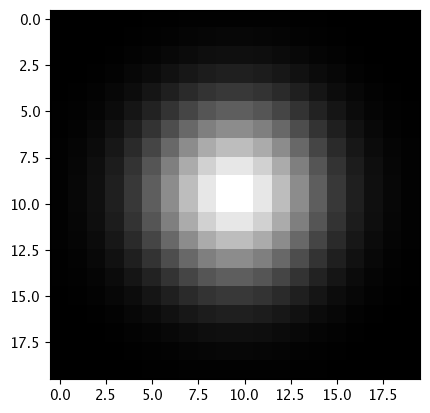

In [6]:
x = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x, y)
Z = np.exp(-(X**2 + Y**2) / 2) / (2 * np.pi)
plt.imshow(Z, cmap='gray')
plt.show()

 **Edge detection with Sobel operator**
 
The Sobel operator is a popular edge detection algorithm that:
 - Detects edges by calculating gradients in the image
 - Uses two 3x3 kernels (one for horizontal and one for vertical edges)
 - Finds both magnitude and direction of edges
 - Commonly used in image processing and computer vision tasks

---
## 4. Python File Handling

**Concept.**
Files let your programs persist data.

* Use built‑in `open(path, mode)` inside a **context manager** (`with`) to ensure automatic close.  
* Modes: `'r'` read, `'w'` write (truncate), `'a'` append, `'b'` binary, `'+'` read/write.

Best practice: work with paths using `pathlib.Path`. 

In [44]:
from pathlib import Path
import time
path = Path('demo.txt')  # will create the file if it doesn't exist
with path.open('w') as f:
    f.write(f'first line {datetime.now()}\n')
    time.sleep(1)
    f.write(f'second line {datetime.now()}')

with path.open('r') as f:
    data = f.read()
    # print line by line
    for line in data.split('\n'):
        print(line)

first line 2025-06-14 13:50:56.601441
second line 2025-06-14 13:50:57.605721


Load image from a file:

Accessing metadata:

### ✍️ Exercise: your turn!
Smooth the image and save it to disk.

Hint: use `skimage.io.imsave` to save the image.

To check the result, you can load the image and display it:

---
## 6. Mini project: Exploring a multi-channel fluorescence microscopy image

In this mini project, we will:
1. Load and examine a 3D multi-channel fluorescence microscopy image
2. Calculate basic statistics for each channel
3. Visualize the distribution of intensities
4. Create maximum intensity projections

First, let's load the image and examine its structure:

Save the image to disk for later use:

---
## 7. Visualizing images with napari

**Introduction to napari**

napari is a fast, interactive, multi-dimensional image viewer for Python. It supports:
- 2D, 3D, and time-series images.
- Viewing raw images and masks simultaneously.
- Interactive contrast adjustment, zooming, and layer management.
- It is particularly useful for microscopy images and segmentation tasks.

How to install napari:

For now, we will install napari using the asset system as a bundled app.

Go to https://github.com/napari/napari/releases/tag/v0.6.1, and install the appropriate version for your operating system.


---

## Where to go next?

* **Introduction to image segmentation**.  
